# Histogram representations
_melody-features_ contains several features and classes for computing histograms corresponding to different aspects of melodies. We return these as sparse histogram dictionaries, which require some parsing if we are interested in the individual bins. Here, we work through an example using jSymbolic's `PitchClassHistogram`. 

`PitchClassHistogram` returns a Python **dict** mapping pitch class `0–11` to a count. We will turn that dict into two plots, using one melody from the bundled Essen Folksong Collection.

First, we plot the pitch-class histogram, then overlay the corresponding Krumhansl–Kessler (1982) profile for comparison.

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from melody_features import infer_key_from_pitches
from melody_features.corpus import essen_corpus
from melody_features.feature_histogram import PitchClassHistogram
from melody_features.io.midi import load_midi

In [39]:
midi_path = essen_corpus / "elsass15.mid"
melody = load_midi(str(midi_path))
if melody is None:
    raise RuntimeError(f"Could not load {midi_path}")

print(midi_path.name, len(melody.pitches), "notes")
print("MIDI key:", melody.key_signature)
root, mode = infer_key_from_pitches(melody.pitches)
print("KS inferred key:", root, mode)

elsass15.mid 88 notes
MIDI key: ('C', 'major')
KS inferred key: C major


## Pitch-class histogram

Fill missing classes with zero, then plot count against pitch class.

In [41]:
PC_NAMES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

pc_hist = PitchClassHistogram(melody.pitches).histogram
pc_counts = np.array([pc_hist.get(i, 0) for i in range(12)], dtype=float)
pc_hist

{0: 26, 1: 0, 2: 7, 3: 0, 4: 8, 5: 11, 6: 0, 7: 19, 8: 0, 9: 11, 10: 0, 11: 6}

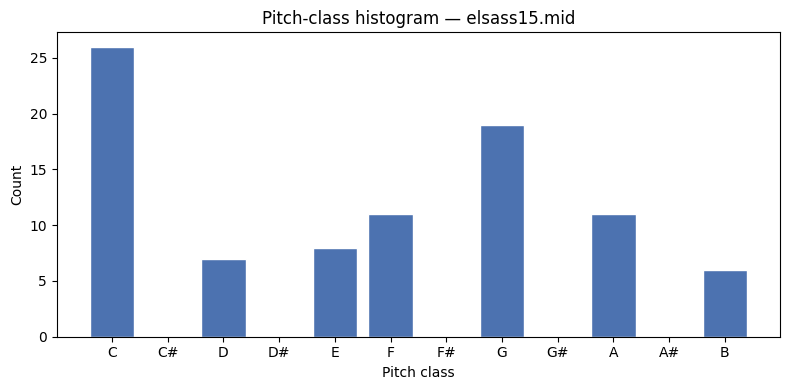

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(PC_NAMES, pc_counts, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Pitch class")
ax.set_ylabel("Count")
ax.set_title(f"Pitch-class histogram — {midi_path.name}")
fig.tight_layout()
plt.show()

## Overlay the KK profile

Estimate the key, rotate the KK major or minor profile to that tonic, and plot it on the same pitch-class axis. Both series are normalised to sum to 1 so the shapes are comparable.

Estimated key: C major


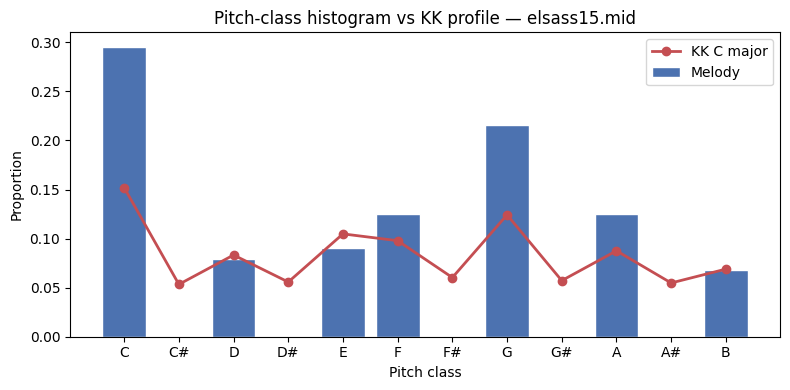

In [43]:
KK_MAJOR = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
KK_MINOR = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

root, mode = infer_key_from_pitches(melody.pitches)
tonic = PC_NAMES.index(root.upper())
profile = KK_MAJOR if mode == "major" else KK_MINOR
kk_aligned = np.roll(profile / profile.sum(), tonic)
pc_prop = pc_counts / pc_counts.sum()

print(f"Estimated key: {root} {mode}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(PC_NAMES, pc_prop, color="#4C72B0", edgecolor="white", label="Melody")
ax.plot(PC_NAMES, kk_aligned, color="#C44E52", marker="o", linewidth=2, label=f"KK {root} {mode}")
ax.set_xlabel("Pitch class")
ax.set_ylabel("Proportion")
ax.set_title(f"Pitch-class histogram vs KK profile — {midi_path.name}")
ax.legend()
fig.tight_layout()
plt.show()